# Understanding Your Data

Before training machine learning models or performing transformations, we must thoroughly examine our dataset.

In this notebook, we systematically explore:
1. **Structural inspection:** `shape`, `columns`, `dtypes`, and `info()`
2. **Statistical summaries:** `describe()` for numerical and categorical data
3. **Data hygiene:** Detecting missing values (`isnull()`) and duplicate rows (`duplicated()`)
4. **Cardinality analysis:** `unique()`, `nunique()`, and `value_counts()`
5. **Correlation analysis:** `corr()`, correlation matrix, and heatmap visualization
6. **Critical thinking:** Correlation vs. Causation in practice

---


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for clean plots
sns.set_theme(style="whitegrid")

# Load the Titanic dataset
df = pd.read_csv('../../data/titanic.csv')

# Verify the initial load
df.head(3)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2. Structural Inspection: `shape`, `columns`, `dtypes`, and `info()`

### `shape`
`shape` returns a tuple `(rows, columns)` telling us the dimensionality of our dataset.


In [2]:
# Inspect total rows and columns
rows, cols = df.shape
print(f"Total Rows (Observations): {rows}")
print(f"Total Columns (Features):  {cols}")


Total Rows (Observations): 891
Total Columns (Features):  12


### Observation
The Titanic dataset contains **891 rows** (passengers) and **12 columns** (features including the target `Survived`).


### `columns`
`columns` returns the names of all features. Checking this confirms there are no strange characters or unintentional leading/trailing spaces in column names.


In [3]:
# List all column names
print("Column Names:")
print(df.columns.tolist())


Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


### `dtypes`
Data types indicate whether each column is stored as integers (`int64`), floating-point decimals (`float64`), or text/categorical objects (`object`).


In [4]:
# Check the data type of each column
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Observation
- `PassengerId`, `Survived`, `Pclass`, `SibSp`, and `Parch` are integers.
- `Age` and `Fare` are continuous floating-point numbers.
- `Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked` are stored as text (`object`).


### `info()`
`info()` provides an all-in-one diagnostic view: column names, non-null counts, data types, and total memory usage.


In [5]:
# Display complete dataset summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Observation
Out of 891 entries:
- `Age` has 714 non-null entries (177 missing values).
- `Cabin` has only 204 non-null entries (687 missing values).
- `Embarked` has 889 non-null entries (2 missing values).
- Total memory usage is approximately ~83.7 KB.


## 3. Summary Statistics: `describe()`

`describe()` computes summary metrics for numerical variables: count, mean, standard deviation, minimum, quartiles (25%, 50%, 75%), and maximum.


In [6]:
# Five-number summary and central tendency for numerical features
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observation
- **`Survived`**: Mean is ~0.384, meaning approximately **38.4%** of passengers in this sample survived.
- **`Age`**: Ranges from **0.42** years (infant) to **80.0** years, with a median of **28.0** and mean of **29.7**.
- **`Fare`**: Has an extreme spread! Minimum is £0.00, 75% of passengers paid <= £31.00, but the maximum is **£512.33**. This massive gap between the 75th percentile and the max indicates severe right-skewness and potential outliers.


### `describe(include='all')`
To include text and categorical features, pass `include='all'`. For categorical columns, Pandas reports `unique`, `top` (mode), and `freq` (count of the mode).


In [7]:
# Summary statistics for both numerical and categorical features
df.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


### Observation
- **`Sex`**: 2 unique values; the most frequent (`top`) is `'male'` with a frequency of 577 out of 891 (64.8%).
- **`Embarked`**: 3 unique ports; `'S'` (Southampton) is the most frequent port with 644 passengers (72.4%).


## 4. Missing Values: `isnull()` and `isnull().sum()`

Missing data is common in real-world ML. We must detect missing values early to decide whether to impute or drop them.


In [8]:
# Compute exact missing counts and percentages per column
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent.round(2)
})

# Filter only columns that have missing values
missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)


,Missing Count,Missing Percentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### Observation
- **`Cabin`**: 77.1% missing. Because over three-quarters of the data is absent, imputation is unreliable. Usually we either drop this column or create an indicator feature (`HasCabin = 1/0`).
- **`Age`**: 19.87% missing. Age is an important predictor, so it will require careful imputation (e.g., using median by passenger class and gender).
- **`Embarked`**: Only 2 values (0.22%) are missing. We can easily fill these with the mode (`'S'`).


## 5. Duplicate Values: `duplicated()` and `duplicated().sum()`

Duplicate rows can bias an ML model by artificially boosting weights on repeated data.


In [9]:
# Check for completely identical rows across all columns
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")


Total duplicate rows: 0


### Observation
There are **0 completely duplicated rows** in the Titanic dataset because `PassengerId` is a strictly unique primary key.


## 6. Unique Values & Cardinality: `unique()`, `nunique()`, and `value_counts()`

**Cardinality** refers to the number of distinct values in a feature. High cardinality features require different encoding strategies compared to low cardinality features.


In [10]:
# Cardinality (number of unique values) for each column
df.nunique()


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

### Observation
- Low cardinality: `Survived` (2), `Sex` (2), `Pclass` (3), `Embarked` (3).
- High cardinality: `PassengerId` (891), `Name` (891), `Ticket` (681).


### Frequency Distribution with `value_counts()`
`value_counts()` gives the exact breakdown of categories. Using `normalize=True` converts the counts into percentages.


In [11]:
# Breakdown of passenger class counts and percentages
pclass_counts = df['Pclass'].value_counts()
pclass_pct = df['Pclass'].value_counts(normalize=True) * 100

pd.DataFrame({'Count': pclass_counts, 'Percentage (%)': pclass_pct.round(2)})


,Count,Percentage (%)
Pclass,,
3,491,55.11
1,216,24.24
2,184,20.65


### Observation
Over **55%** of all passengers were traveling in 3rd class (491 passengers), while 1st class accounted for ~24% and 2nd class ~21%.


## 7. Correlation Analysis: `corr()` and Heatmap

Correlation quantifies the strength of a **linear relationship** between two numerical features:
- Pearson correlation coefficient ($r$) ranges from $-1.0$ (perfect inverse relationship) to $+1.0$ (perfect direct relationship).
- An $r$ close to $0$ means no linear relationship.


In [12]:
# Compute the correlation matrix for numerical features
corr_matrix = df.corr(numeric_only=True)
corr_matrix.round(3)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000,-0.005,-0.035,0.037,-0.058,-0.002,0.013
Survived,-0.005,1.000,-0.338,-0.077,-0.035,0.082,0.257
Pclass,-0.035,-0.338,1.000,-0.369,0.083,0.018,-0.549
Age,0.037,-0.077,-0.369,1.000,-0.308,-0.189,0.096
SibSp,-0.058,-0.035,0.083,-0.308,1.000,0.415,0.160
Parch,-0.002,0.082,0.018,-0.189,0.415,1.000,0.216
Fare,0.013,0.257,-0.549,0.096,0.160,0.216,1.000


### Visualizing with a Correlation Heatmap
A heatmap uses color to make patterns immediately apparent.


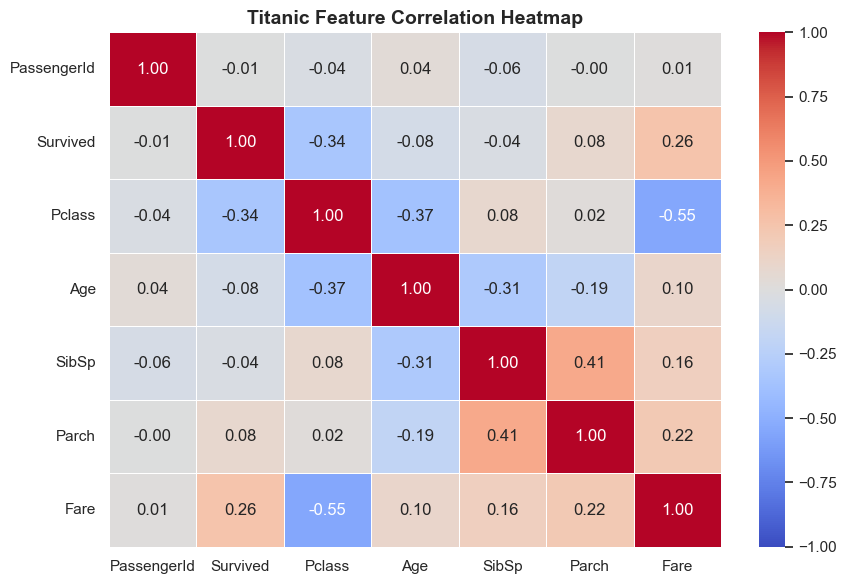

In [13]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

plt.title('Titanic Feature Correlation Heatmap', fontsize=14, weight='bold')
plt.tight_layout()

# Save the plot
plt.savefig('../../outputs/plots/correlation_heatmap.png', dpi=150)
plt.show()


### Observation
Key correlation findings:
1. **`Pclass` & `Fare` ($r = -0.55$)**: A moderate negative correlation. Higher class numbers (3rd class) paid substantially lower fares than 1st class.
2. **`Pclass` & `Survived` ($r = -0.34$)**: Negative correlation indicating passengers in higher numerical classes (3rd class) had lower survival rates.
3. **`Fare` & `Survived` ($r = +0.26$)**: Positive correlation showing that passengers who paid higher fares had higher survival rates.
4. **`SibSp` & `Parch` ($r = +0.41$)**: Positive correlation between siblings/spouses and parents/children, representing traveling family units.


## 8. Correlation vs. Causation: Critical ML Thinking

A fundamental rule in statistics and machine learning:
> **Correlation does NOT imply Causation.**

### The Danger:
In our heatmap, `Fare` has a positive correlation with `Survived` ($r = +0.26$).
Does that mean paying more money magically *caused* a passenger to survive?

**No.**
1. **Confounding Variable (Socioeconomic Status & Cabin Location):**
   - Passengers who paid higher fares were placed in 1st Class cabins located on the upper decks of the ship.
   - Upper decks were physically closest to the lifeboats.
   - During evacuation, crew protocols prioritized 1st Class passengers ("women and children in 1st class first").
2. **The Mechanism:**
   - The *physical proximity to lifeboats* and *evacuation priority* caused higher survival, not the money itself. `Fare` is simply an indicator (proxy) for that underlying advantage.

Always look for confounding variables before making real-world claims based on correlation!


### Key Takeaways
1. Always start every analysis with `shape`, `dtypes`, and `info()` to detect types and missingness.
2. Use `describe()` to spot skewness and extreme outliers (such as `Fare` spanning from 0 to 512).
3. Compute exact missing percentages to plan your imputation strategy.
4. Use `corr()` and heatmaps to inspect linear relationships, but never confuse correlation with real-world causation.
